# Assignment 3 — CIFAR-10: LeNet-5 & ZFNet (walkthrough)

Computer Vision · Deep Learning for Computer Vision

---

## How this notebook fits the project

This file is a **thin narrative**: markdown + short runnable cells that **import** the real code.

| Artifact          | Role                                                                                                   |
| ----------------- | ------------------------------------------------------------------------------------------------------ |
| `lenet5.py`       | **Canonical** LeNet-5: model, 32×32 CIFAR loaders, training, plots — **fully annotated** (rubric).     |
| `zfnet.py`        | **Canonical** ZFNet: model, 224×224 upsampled CIFAR, training, comparison plots — **fully annotated**. |
| `main.py`         | **Full pipeline** from the terminal: both models, 50 epochs, checkpoints, JSON histories.              |
| **This notebook** | Story + quick sanity run (few epochs) or your own longer runs **in the kernel**.                       |

**Dataset:** [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) — 50k train / 10k test, 32×32 RGB, 10 classes. LeNet keeps **32×32**; ZFNet uses **224×224** upsampling (see `zfnet.py`).


## 1. Environment

Use the project `venv` and install dependencies once:

```bash
python3 -m venv venv
source venv/bin/activate
pip install -r requirements.txt
```

Open this notebook with the **same interpreter** (`venv`) as the kernel.


In [1]:
%matplotlib inline

import json
import os

import torch

from lenet5 import (
    LeNet5,
    get_cifar10_loaders,
    train_model as train_lenet,
    plot_training_curves as plot_lenet_curves,
    count_parameters as count_lenet_params,
)
from zfnet import (
    ZFNet,
    get_cifar10_loaders_zfnet,
    train_model as train_zfnet,
    plot_training_curves as plot_zf_curves,
    compare_architectures,
    count_parameters as count_zf_params,
)

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

os.makedirs("outputs", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

[INFO] Using device: cpu
[INFO] Using device: cpu
Device: cpu


## 2. Demo vs. full training

- **Notebook (below):** small `NUM_EPOCHS_*` to verify the pipeline quickly. ZFNet on **CPU** is slow — keep epochs low unless you have a GPU.
- **Full runs (recommended for final results):** from the project root:

```bash
python main.py
python main.py --lenet
python main.py --zfnet
python main.py --compare
```


In [2]:
NUM_EPOCHS_LENET = 20
NUM_EPOCHS_ZFNET = 10
BATCH_LENET = 128
BATCH_ZFNET = 64
NUM_CLASSES = 10

## 3. LeNet-5 (32×32 RGB)

Details and tensor shapes: open **`lenet5.py`**.  
Input batch shape: **`[N, 3, 32, 32]`** → logits **`[N, 10]`**.


In [3]:
train_l, test_l = get_cifar10_loaders(batch_size=BATCH_LENET)
lenet = LeNet5(num_classes=NUM_CLASSES).to(device)
count_lenet_params(lenet)

history_lenet = train_lenet(
    lenet,
    train_l,
    test_l,
    num_epochs=NUM_EPOCHS_LENET,
    model_name="LeNet-5 (notebook)",
    device=device,
)

[INFO] Training samples : 50000
[INFO] Test samples     : 10000
[INFO] LeNet-5 pipeline: spatial size 32×32 (native CIFAR-10).
[INFO] Total trainable parameters: 62,006

  Training LeNet-5 (notebook) on CIFAR-10
  Epochs      : 2
  Batch Size  : 128
  Optimizer   : SGD (lr=0.01, momentum=0.9)
  Scheduler   : StepLR (step=20, gamma=0.1)
  Device      : cpu

Epoch [  1/2] | Train Loss: 1.9667 | Train Acc: 28.19% | Test Loss: 1.7799 | Test Acc: 37.31%

[DONE] Final Test Accuracy: 41.59%


[INFO] Plot saved to outputs/lenet5_curves_notebook.png


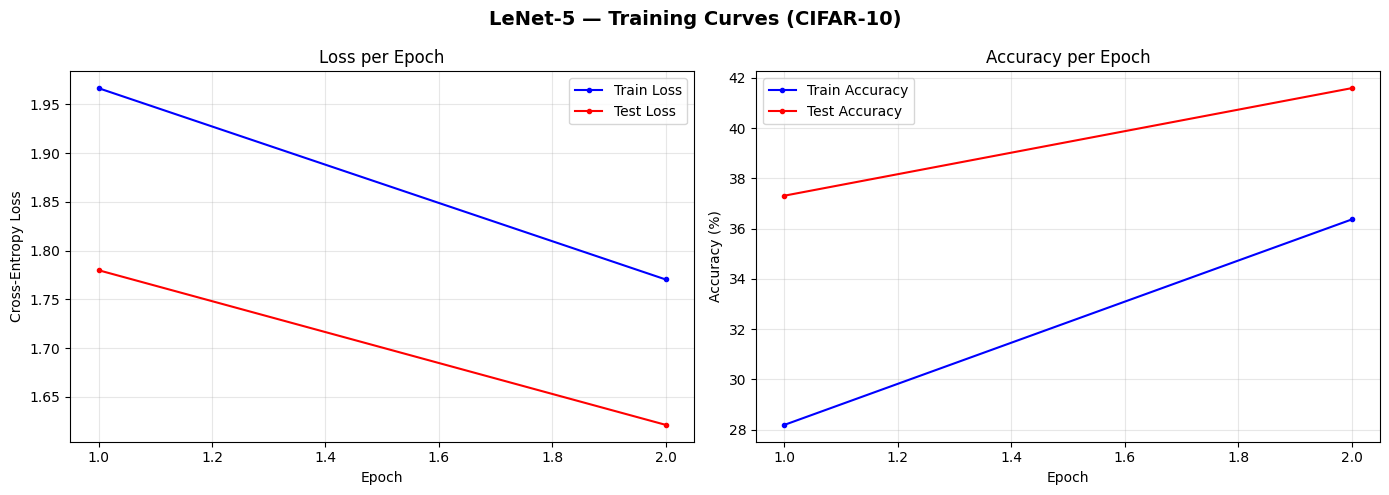

In [4]:
plot_lenet_curves(
    history_lenet,
    model_name="LeNet-5",
    save_path="outputs/lenet5_curves_notebook.png",
)

with open("outputs/lenet5_history_notebook.json", "w") as f:
    json.dump(history_lenet, f, indent=2)

## 4. ZFNet (224×224 upsampled)

Details: **`zfnet.py`**.  
Input batch shape: **`[N, 3, 224, 224]`** → logits **`[N, 10]`**.


In [5]:
train_z, test_z = get_cifar10_loaders_zfnet(batch_size=BATCH_ZFNET)
zf = ZFNet(num_classes=NUM_CLASSES).to(device)
count_zf_params(zf)

history_zf = train_zfnet(
    zf,
    train_z,
    test_z,
    num_epochs=NUM_EPOCHS_ZFNET,
    model_name="ZFNet (notebook)",
    device=device,
)

[INFO] Training samples : 50000
[INFO] Test samples     : 10000
[INFO] ZFNet pipeline: spatial size 224×224 (upsampled from 32×32).
[INFO] Total trainable parameters: 58,301,578

  Training ZFNet (notebook) on CIFAR-10 (224×224)
  Epochs      : 1
  Batch Size  : 64
  Optimizer   : SGD (lr=0.01, momentum=0.9, wd=5e-4)
  Scheduler   : StepLR (step=20, gamma=0.1)
  Device      : cpu

Epoch [  1/1] | Train Loss: 2.2058 | Train Acc: 16.23% | Test Loss: 1.9449 | Test Acc: 26.96%
  [CHECKPOINT] New best test accuracy: 26.96%

[DONE] Best Test Accuracy: 26.96%


[INFO] Plot saved to outputs/zfnet_curves_notebook.png


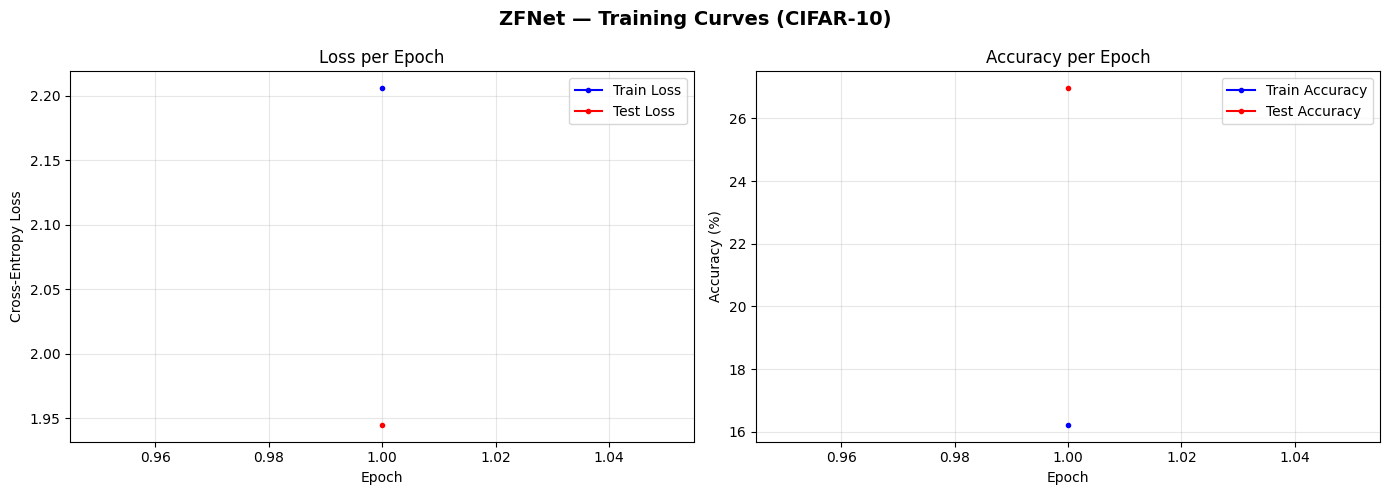

In [6]:
plot_zf_curves(
    history_zf,
    model_name="ZFNet",
    save_path="outputs/zfnet_curves_notebook.png",
)

with open("outputs/zfnet_history_notebook.json", "w") as f:
    json.dump(history_zf, f, indent=2)

## 5. Side-by-side comparison (this session)

Run after both training cells above completed in the **same kernel**.


[INFO] Comparison plot saved to outputs/comparison_curves_notebook.png


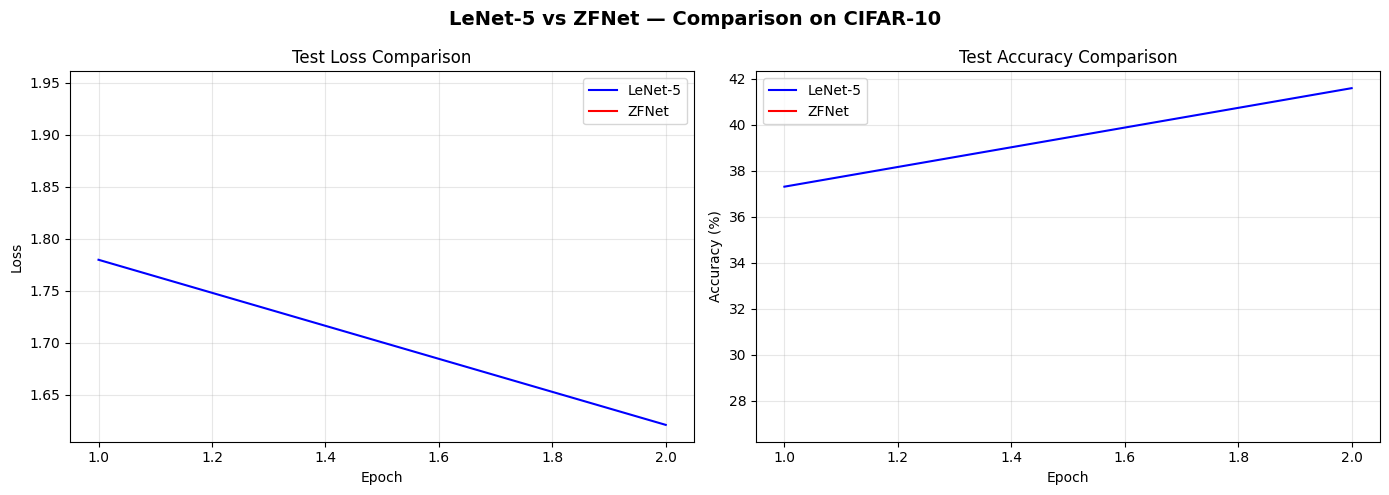

Best test acc — LeNet: 41.59 | ZFNet: 26.96


In [7]:
compare_architectures(
    history_lenet,
    history_zf,
    save_path="outputs/comparison_curves_notebook.png",
)

print(
    "Best test acc — LeNet:",
    max(history_lenet["test_acc"]),
    "| ZFNet:",
    max(history_zf["test_acc"]),
)

## 6. Optional: compare `main.py` JSON outputs

After `python main.py`, you can load the saved histories and plot without retraining.


In [8]:
LOAD_FROM_MAIN = False

if LOAD_FROM_MAIN:
    with open("outputs/lenet5_history.json") as f:
        h_l = json.load(f)
    with open("outputs/zfnet_history.json") as f:
        h_z = json.load(f)
    compare_architectures(
        h_l, h_z, save_path="outputs/comparison_from_main.png"
    )